### build basic chatbot

componenets of langgraph
1. edges
2. nodes
3. state

In [ ]:
# --- The LangGraph mental model: a graph IS an agent (NOTES.md §2) ---
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain.chat_models import init_chat_model

# State = the single object passed node-to-node. TypedDict is just a dict with a
# declared shape (state["messages"] at runtime). The Annotated metadata attaches a
# *reducer*: add_messages means "append" instead of overwrite, so conversation
# history accumulates each turn rather than being lost. (NOTES.md §2, §9)
class State(TypedDict):
    messages:Annotated[list,add_messages]

graph_builder=StateGraph(State)        # blank flowchart tied to State
llm=init_chat_model("ollama:qwen3:8b")

## node — just a function: state -> partial update. Return only what changes;
## the reducer merges it in. (NOTES.md §2)
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

## graph — wire the boxes and arrows. This is a plain chatbot: a straight line
## START -> chatbot -> END that runs once, no tools, no loop. (NOTES.md §3)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

## compile — turns the drawn graph into a runnable object you can .invoke()/.stream()
graph=graph_builder.compile()


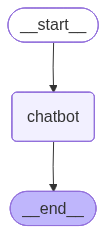

In [4]:
## visualize
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [5]:
graph.invoke({"messages":"Hi"})

{'messages': [HumanMessage(content='Hi', additional_kwargs={}, response_metadata={}, id='b112edb7-4870-4f01-8cc8-bcc179ad81db'),
  AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-06-11T21:44:26.3065815Z', 'done': True, 'done_reason': 'stop', 'total_duration': 19330644400, 'load_duration': 13990654100, 'prompt_eval_count': 11, 'prompt_eval_duration': 200344000, 'eval_count': 87, 'eval_duration': 5122925000, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--019eb8a4-783d-74a0-a9cf-7af41b374692-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 87, 'total_tokens': 98})]}

In [6]:
for event in graph.stream({"messages":"Hi"}):
    for value in event.values():
        print(value)

{'messages': [AIMessage(content='Hello! How can I assist you today? 😊', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-06-11T21:44:35.5961134Z', 'done': True, 'done_reason': 'stop', 'total_duration': 9275193600, 'load_duration': 403709900, 'prompt_eval_count': 11, 'prompt_eval_duration': 59845000, 'eval_count': 146, 'eval_duration': 8793554000, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--019eb8a4-c3cf-71a0-9c6a-1db9fb24818c-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 146, 'total_tokens': 157})]}


### TOOLING

In [ ]:
# --- From plain chatbot to ReAct agent: add tools + a conditional edge (NOTES.md §3, §4) ---
from langchain_tavily import TavilySearch
from dotenv import load_dotenv
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

load_dotenv()  # TavilySearch needs TAVILY_API_KEY from a local .env

tool=TavilySearch(max_results=2)
tool.invoke("what is langgraph?")

def multiply(a:int, b:int)->int:
    """Return multiplication of two int"""   # docstring = the description the LLM sees
    return a*b

tools = [tool,multiply]
llm_with_tool=llm.bind_tools(tools)   # native tool-calling: model can emit tool_calls

# The model node decides whether to answer or to call a tool (NOTES.md §3)
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))   # ToolNode runs whatever tool the model picked

builder.add_edge(START, "tool_calling_llm")
# Conditional edge = ROUTING, not pausing (don't conflate with interrupt — NOTES.md §4).
# tools_condition is the prebuilt router: "did the last AIMessage contain tool_calls?"
#   yes -> "tools"   |   no -> END
builder.add_conditional_edges(
        "tool_calling_llm", 
        tools_condition
    )
# NOTE: tools -> END here means it runs a tool once then stops (no loop back to the
# model), so the tool result isn't summarized into a final answer. The next cell with
# MemorySaver wires tools -> tool_calling_llm to close the ReAct loop instead.
builder.add_edge("tools", END)
graph=builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:

graph.invoke({"messages":"What is the recent ai news ?"})

{'messages': [HumanMessage(content='What is the recent ai news ?', additional_kwargs={}, response_metadata={}, id='ebaab2d1-fdb4-44a1-8de3-bee59403b7c4'),
  AIMessage(content='', additional_kwargs={}, response_metadata={'model': 'qwen3:8b', 'created_at': '2026-06-11T21:57:06.4929739Z', 'done': True, 'done_reason': 'stop', 'total_duration': 23439329200, 'load_duration': 8973209900, 'prompt_eval_count': 1474, 'prompt_eval_duration': 1327187000, 'eval_count': 204, 'eval_duration': 13082807000, 'logprobs': None, 'model_name': 'qwen3:8b', 'model_provider': 'ollama'}, id='lc_run--019eb8b0-01a1-7330-ad22-66dbb6ba5ad8-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'AI news', 'time_range': 'day', 'topic': 'news'}, 'id': '8b3b2e91-d209-4dc4-bc20-a8dd88b54e15', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1474, 'output_tokens': 204, 'total_tokens': 1678}),
  ToolMessage(content='{"query": "AI news", "follow_up_questions": null, "answer": null, "images

In [10]:
response=graph.invoke({"messages":"What is 3 multiplied by 5?"})
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is 3 multiplied by 5?
================================== Ai Message ==================================
Tool Calls:
  multiply (1ba9fcd2-4e19-48e1-b689-7e5229eaada4)
 Call ID: 1ba9fcd2-4e19-48e1-b689-7e5229eaada4
  Args:
    a: 3
    b: 5
================================= Tool Message =================================
Name: multiply

15


In [ ]:
# --- Closing the ReAct loop + adding memory with a checkpointer (NOTES.md §3, §5) ---
from langgraph.checkpoint.memory import MemorySaver

# Checkpointer = persistence of state between calls. Without one the agent is
# amnesiac — every invoke starts blank. MemorySaver keeps snapshots in RAM
# (dev/demo only); swap for SqliteSaver/PostgresSaver in production. (NOTES.md §5)
memory_saver=MemorySaver()
builder1=StateGraph(State)
builder1.add_node("tool_calling_llm",tool_calling_llm)
builder1.add_node("tools",ToolNode(tools))

builder1.add_edge(START, "tool_calling_llm")
builder1.add_conditional_edges(
        "tool_calling_llm", 
        tools_condition
    )
# This is the loop that makes it a real ReAct agent: model -> tool -> back to model
# (reason -> act -> observe -> repeat) until the model stops calling tools. (NOTES.md §3)
builder1.add_edge("tools", "tool_calling_llm")
graph1=builder1.compile(checkpointer=memory_saver)
# config/thread_id picks WHICH conversation. The checkpointer keys history by
# thread_id; different threads = isolated histories. One compiled graph serves all
# users — you do NOT build an agent per user (NOTES.md §5).
config={"configurable":{"thread_id":"1"}}
display(Image(graph1.get_graph().draw_mermaid_png()))

In [17]:
# response=graph1.invoke({"messages":"give me some recent ai news ? and What is 3 multiplied by 5?"})
# for m in response["messages"]:
#     m.pretty_print()

response=graph1.invoke({"messages":"HI my name is chris"},config=config)
for m in response["messages"]:
    m.pretty_print()

response=graph1.invoke({"messages":"what my name?"},config=config)
for m in response["messages"]:
    m.pretty_print()



================================ Human Message =================================

HI my name is chris
================================== Ai Message ==================================

Hello, Chris! How can I help you today? 😊
================================ Human Message =================================

HI my name is chris
================================== Ai Message ==================================

Hello again, Chris! 😊 How can I assist you today?
================================ Human Message =================================

HI my name is chris
================================== Ai Message ==================================

Hello, Chris! How can I help you today? 😊
================================ Human Message =================================

HI my name is chris
================================== Ai Message ==================================

Hello again, Chris! 😊 How can I assist you today?
================================ Human Message =================================